# 01 - Exploration of the UFC data

What the data contain, and the properties of the data that shape the modelling choices. It reads the tables written by [UFC_Pipeline](../UFC_Pipeline.ipynb) in `data/processed/`: run that notebook first.

1. Coverage
2. The corner artefact
3. How fights end
4. Round by round
5. The judges
6. Data quality
7. The betting market
8. Official rankings
9. Professional records

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import spearmanr

from ufc_rating import plotting
from ufc_rating.config import DIVISIONS, MASTER_CSV, ROUNDS_CSV, WIKI_RANKINGS_CSV, WIKI_RECORDS_CSV
from ufc_rating.processing.master import american_to_prob, read_master, read_official_rankings, read_rounds

plotting.setup()
master = read_master(MASTER_CSV)
master['year'] = master['date'].dt.year
rounds = read_rounds(ROUNDS_CSV)

## 1. Coverage

8,905 fights, 790 events, 2,760 fighters, 20,904 rounds with statistics
From 1993-11-12 (UFC 1) to 2026-09-19


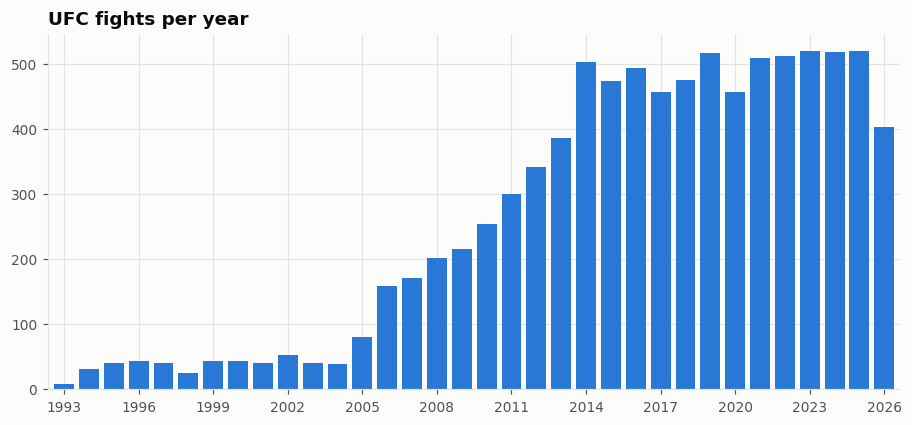

In [2]:
fighters = pd.concat([master['r_id'], master['b_id']]).nunique()
print(f"{len(master):,} fights, {master['event_id'].nunique():,} events, {fighters:,} fighters, {len(rounds):,} rounds with statistics")
print(f"From {master['date'].min().date()} (UFC 1) to {master['date'].max().date()}")

per_year = master.groupby('year').size()
ax = per_year.plot.bar(width=0.8, color=plotting.BLUE)
ax.set_title('UFC fights per year')
ax.set_xlabel('')
ax.set_xticks(range(0, len(per_year), 3))
ax.set_xticklabels(per_year.index[::3], rotation=0)
plt.show()

The UFC ran a handful of events a year until the mid-2000s. The Fight Night format, the TV deals and the international cards then pushed it to 400-500 fights a year. Most of the data, and therefore most of what the models learn, comes from the last fifteen years.

In [3]:
divisions = (master.dropna(subset=['division'])
             .groupby('division')
             .agg(fights=('fight_id', 'size'), first=('date', 'min'), last=('date', 'max'))
             .reindex(DIVISIONS))
divisions['first'] = divisions['first'].dt.date
divisions['last'] = divisions['last'].dt.date
unassigned = master['division'].isna().sum()
print(f'{unassigned} fights without a division (catch weight, open weight, early tournaments)')
divisions

209 fights without a division (catch weight, open weight, early tournaments)


,fights,first,last
division,,,
Flyweight,431,2012-03-02,2026-09-19
Bantamweight,800,2010-12-04,2026-09-19
Featherweight,890,2010-12-04,2026-09-19
Lightweight,1482,1997-02-07,2026-09-19
Welterweight,1417,1998-10-16,2026-09-12
Middleweight,1170,1997-07-27,2026-09-19
Light Heavyweight,774,1997-12-21,2026-09-19
Heavyweight,791,1997-02-07,2026-09-19
Women's Strawweight,379,2014-07-16,2026-09-05


The twelve divisions did not all exist from the start: women's MMA arrived in 2013, flyweight in 2012 and women's featherweight is a small division. The fights labelled "catch weight" or "open weight" have no division; they still count in the fighters' records.

## 2. The corner artefact

Each fight lists two fighters, `r` then `b`. On modern cards `r` is the red corner, usually given to the favourite or the champion. But on ufcstats.com the **winner is listed first in every fight before 2010**: the "red corner" of those years is not a corner at all.

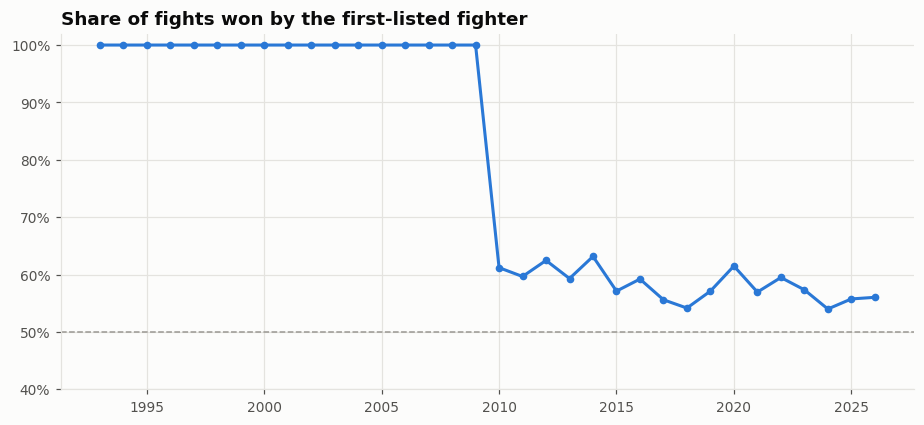

Since 2010 the red corner wins 58.0% of decided fights and is the betting favourite in 61.7% of them.


In [4]:
decided = master[master['outcome'].isin(['r', 'b'])]
first_listed_wins = (decided['outcome'] == 'r').groupby(decided['year']).mean()

ax = first_listed_wins.plot(color=plotting.BLUE, marker='o', markersize=4)
ax.axhline(0.5, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.4, 1.02)
ax.set_title('Share of fights won by the first-listed fighter')
ax.set_xlabel('')
plt.show()

modern = decided[decided['date'] >= '2010-01-01']
with_odds = modern.dropna(subset=['r_odds', 'b_odds'])
r_favourite = (american_to_prob(with_odds['r_odds']) > american_to_prob(with_odds['b_odds'])).mean()
print(f"Since 2010 the red corner wins {(modern['outcome'] == 'r').mean():.1%} of decided fights "
      f"and is the betting favourite in {r_favourite:.1%} of them.")

Two consequences for the models:

- Taken as they are, the `r`/`b` sides leak the result: a model trained on them would learn "the first-listed fighter wins" from the early years, a rule that says nothing about fighting. The pipeline therefore draws fighter **A** at random from the two corners of each fight (fixed seed), which gives a 50/50 target in every era.
- Since 2010 the red corner does win more often, but because the UFC puts the favourite there, not because the corner itself helps. The models do not see the corner; the fighters' records carry the same information.

## 3. How fights end

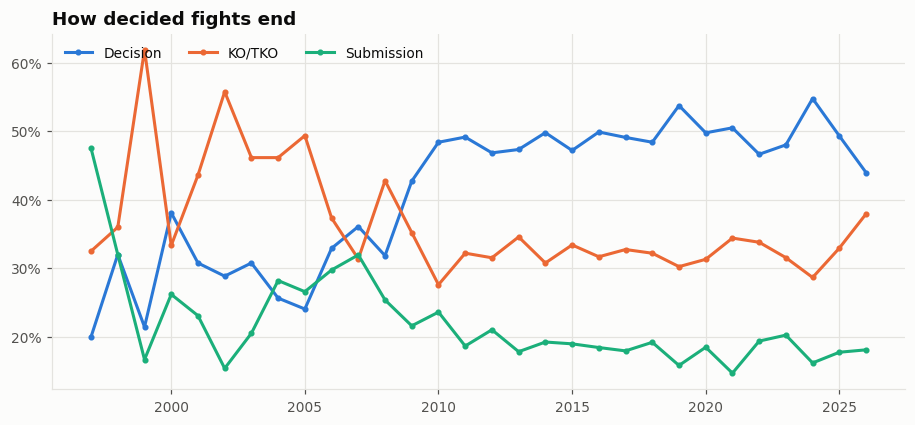

In [5]:
methods = (pd.crosstab(decided['year'], decided['method_group'], normalize='index')
           [['Decision', 'KO/TKO', 'Submission']])
methods = methods[methods.index >= 1997]

ax = methods.plot(marker='o', markersize=3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('How decided fights end')
ax.set_xlabel('')
ax.legend(title=None, ncols=3, loc='upper left')
plt.show()

Knockouts dominated the late 1990s and early 2000s. As fighters became well-rounded, decisions took over around 2009 and now settle about half the fights, while submissions have stayed below 20% since 2010.

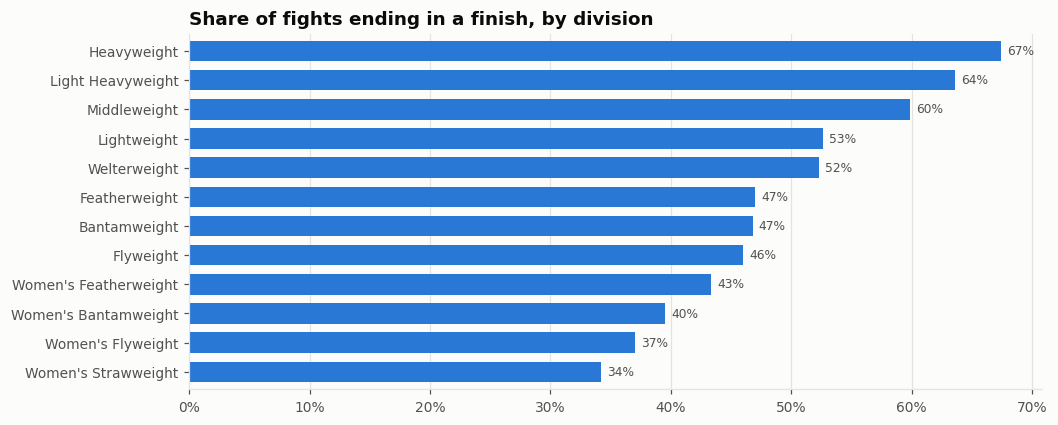

In [6]:
by_division = (decided.dropna(subset=['division'])
               .assign(finish=lambda d: d['method_group'].isin(['KO/TKO', 'Submission']))
               .groupby('division')['finish'].mean()
               .reindex(DIVISIONS).dropna().sort_values())

ax = by_division.plot.barh(color=plotting.BLUE, width=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Share of fights ending in a finish, by division')
ax.set_ylabel('')
ax.grid(axis='y', visible=False)
for y, value in enumerate(by_division):
    ax.text(value + 0.005, y, f'{value:.0%}', va='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

Finishing power grows with weight: two heavyweights end most of their fights early, the lightest divisions go to the judges more often than not. A fighter's finish rate therefore has to be read against their division, which the round-robin model does implicitly by comparing fighters of the same division.

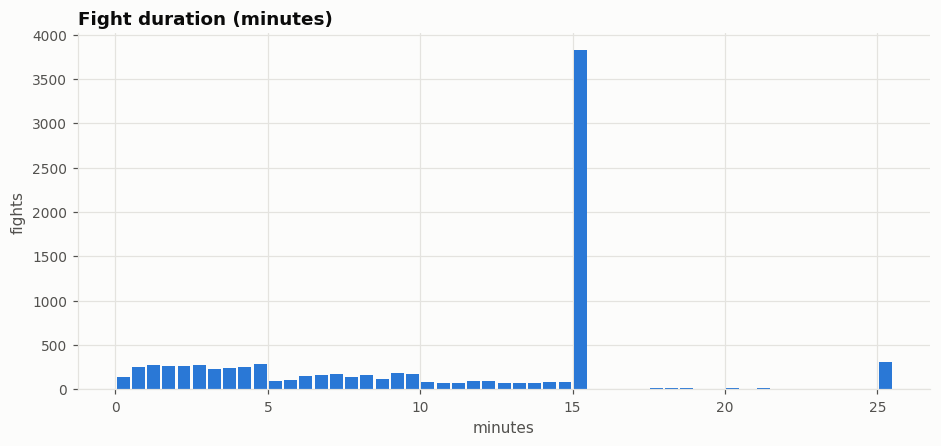

43% of fights last exactly 15 minutes (three-round decision), 3% exactly 25 (five rounds)


In [7]:
minutes = master['fight_seconds'] / 60
ax = minutes.plot.hist(bins=np.arange(0, 26, 0.5), color=plotting.BLUE, rwidth=0.85)
ax.set_title('Fight duration (minutes)')
ax.set_xlabel('minutes')
ax.set_ylabel('fights')
plt.show()
print(f"{(minutes == 15).mean():.0%} of fights last exactly 15 minutes (three-round decision), "
      f"{(minutes == 25).mean():.0%} exactly 25 (five rounds)")

Rates such as strikes per minute are computed over the real fight time, not the scheduled time: a fighter who knocks everyone out in the first round would otherwise look inactive.

**Bonuses.** Since 2014 the UFC awards two kinds of post-fight bonuses: *Fight of the Night* to both fighters of the most entertaining fight, and *Performance of the Night* to the most impressive winners (which replaced *Knockout* and *Submission of the Night*).

In [8]:
recent = decided[decided['date'] >= '2014-01-01']
bonus_text = recent['bonuses'].fillna('')
bonus = pd.DataFrame({
    'Fight of the Night': bonus_text.str.contains('Fight of the Night'),
    'Performance of the Night': bonus_text.str.contains('Performance|Knockout of|Submission of'),
}).groupby(recent['method_group']).mean().reindex(['KO/TKO', 'Submission', 'Decision'])
print(f"{(bonus_text != '').mean():.0%} of the fights since 2014 earned a bonus")
bonus.map('{:.0%}'.format)

28% of the fights since 2014 earned a bonus


,Fight of the Night,Performance of the Night
method_group,,
KO/TKO,6%,44%
Submission,3%,41%
Decision,8%,1%


Performance bonuses go almost only to finishes: a decision win nearly never earns one. Fight of the Night is the only way for a fight that goes the distance to be rewarded.

## 4. Round by round

ufcstats.com records every statistic round by round. Taking only the fights that went the distance (every round is complete, so the rounds are comparable), how does the pace change?

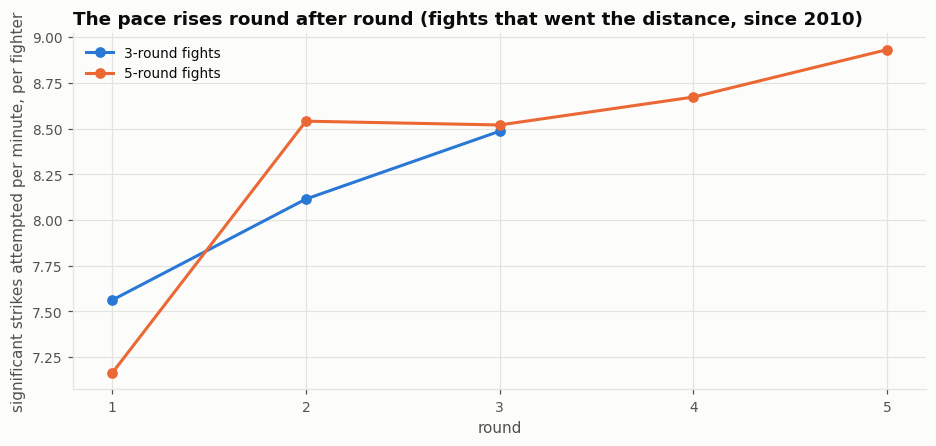

attempts per minute  landed per minute
scheduled round                                        
3         1                     7.56               3.26
          2                     8.11               3.57
          3                     8.49               3.72
5         1                     7.16               3.13
          2                     8.54               3.78
          3                     8.52               3.82
          4                     8.67               3.93
          5                     8.93               4.03

In [9]:
distance = master[master['method_group'] == 'Decision'].set_index('fight_id')
per_round = rounds[rounds['fight_id'].isin(distance.index) & (rounds['date'] >= '2010-01-01')].copy()
per_round['scheduled'] = per_round['fight_id'].map(distance['scheduled_rounds'])
per_round = per_round[per_round['scheduled'].isin([3, 5])]
minutes = per_round['seconds'] / 60
per_round['attempts per minute'] = (per_round['r_sig_att'] + per_round['b_sig_att']) / 2 / minutes
per_round['landed per minute'] = (per_round['r_sig_landed'] + per_round['b_sig_landed']) / 2 / minutes

pace = per_round.groupby(['scheduled', 'round'])[['attempts per minute', 'landed per minute']].mean()
fig, ax = plt.subplots()
for (scheduled, table), color in zip(pace.groupby(level='scheduled'), plotting.SERIES):
    ax.plot(table.index.get_level_values('round'), table['attempts per minute'], marker='o',
            color=color, label=f'{scheduled}-round fights')
ax.set_xticks(range(1, 6))
ax.set_xlabel('round')
ax.set_ylabel('significant strikes attempted per minute, per fighter')
ax.set_title('The pace rises round after round (fights that went the distance, since 2010)')
ax.legend(loc='upper left')
plt.show()
pace.round(2)

Fighters do not slow down on average: in fights that go the distance, the first round is the most cautious, and the last round is the busiest. This is partly a selection effect: the fighters who fade are more likely to be finished, and those fights are not in this sample. The per-fighter version of this pattern (output late in the fight against output early) was tested as a model feature in [02_feature_engineering](02_feature_engineering.ipynb).

In [10]:
first_round = rounds[(rounds['round'] == 1) & rounds['fight_id'].isin(decided['fight_id'])
                     & (rounds['date'] >= '2010-01-01')]
leader = np.sign(first_round['r_sig_landed'] - first_round['b_sig_landed'])
outcome = first_round['fight_id'].map(decided.set_index('fight_id')['outcome'])
winner = np.where(outcome == 'r', 1, -1)
clear = leader != 0
print(f"The fighter who lands more significant strikes in round 1 wins the fight "
      f"{(leader[clear] == winner[clear]).mean():.0%} of the time ({clear.sum():,} fights since 2010).")

The fighter who lands more significant strikes in round 1 wins the fight 71% of the time (7,136 fights since 2010).


## 5. The judges

A decision is scored by three judges, round by round (10-9 to the winner of the round). ufcstats.com lists the three cards; the pipeline orients them to the two fighters.

In [11]:
decisions = master[master['method_group'] == 'Decision'].copy()
decisions['type'] = np.select([decisions['method'].str.contains('Split'), decisions['method'].str.contains('Majority')],
                              ['split', 'majority'], 'unanimous')
since_2010 = decisions[decisions['date'] >= '2010-01-01']
print(since_2010['type'].value_counts(normalize=True).map('{:.1%}'.format).to_string())

scored = since_2010[since_2010['outcome'].isin(['r', 'b'])]
sign = np.where(scored['outcome'] == 'r', 1, -1)
fewer = (scored['r_sig_landed'] - scored['b_sig_landed']) * sign < 0
print(f"\nDecisions won by the fighter who landed FEWER significant strikes: {fewer.mean():.0%}")
fewer.groupby(scored['type']).mean().map('{:.0%}'.format).rename('winner landed fewer')

type
unanimous    77.2%
split        20.4%
majority      2.4%

Decisions won by the fighter who landed FEWER significant strikes: 21%


type
majority     39%
split        38%
unanimous    17%
Name: winner landed fewer, dtype: object

One decision in five goes to the fighter who landed fewer significant strikes, and more than a third of the split decisions. Judges score rounds, not totals, and also weigh takedowns, control and damage: a fighter can lose the strike count and still win two rounds out of three. Split and majority decisions are genuinely close fights, which is why the Elo rating counts them as half a win (see [03_models_and_rankings](03_models_and_rankings.ipynb)).

In [12]:
three = scored[scored['scheduled_rounds'] == 3]
cards = pd.concat([three[[f'judge{j}_r_score', f'judge{j}_b_score']].set_axis(['r', 'b'], axis=1)
                   for j in (1, 2, 3)]).dropna()
cards = cards[(cards['r'] + cards['b']) >= 55]
label = cards.max(axis=1).astype(int).astype(str) + '-' + cards.min(axis=1).astype(int).astype(str)
label.value_counts(normalize=True).head(5).map('{:.0%}'.format).rename('share of cards, 3-round decisions')

29-28    52%
30-27    38%
30-26     5%
29-27     3%
30-25     1%
Name: share of cards, 3-round decisions, dtype: object

## 6. Data quality

In [13]:
fields = {
    'reach': ['r_reach_cm', 'b_reach_cm'],
    'date of birth': ['r_dob', 'b_dob'],
    'height': ['r_height_cm', 'b_height_cm'],
    'stance': ['r_stance', 'b_stance'],
    'control time': ['r_ctrl_sec', 'b_ctrl_sec'],
    'betting odds': ['r_odds', 'b_odds'],
    'official rank (either fighter)': ['r_rank', 'b_rank'],
}
quality = pd.DataFrame({
    name: {'missing (all fights)': master[cols].isna().any(axis=1).mean(),
           'missing (since 2015)': master.loc[master['year'] >= 2015, cols].isna().any(axis=1).mean()}
    for name, cols in fields.items()
}).T
quality['missing (all fights)'] = quality['missing (all fights)'].map('{:.1%}'.format)
quality['missing (since 2015)'] = quality['missing (since 2015)'].map('{:.1%}'.format)
quality

,missing (all fights),missing (since 2015)
reach,11.9%,2.5%
date of birth,1.4%,0.0%
height,0.3%,0.0%
stance,1.0%,0.4%
control time,2.4%,0.0%
betting odds,19.2%,5.8%
official rank (either fighter),84.7%,79.1%


- Physical data is nearly complete; reach is the weakest field, mostly for fighters of the 1990s and 2000s.
- Control time was not recorded before UFC 21 in July 1999 (ufcstats shows 0:00 for both fighters). Those zeros are treated as missing, not as "no control".
- Odds start in 2010. Official ranks exist only for ranked fighters (top 15 of each division) and are therefore missing for most fights by nature: they describe the fights and check the rankings, they are not a model input.

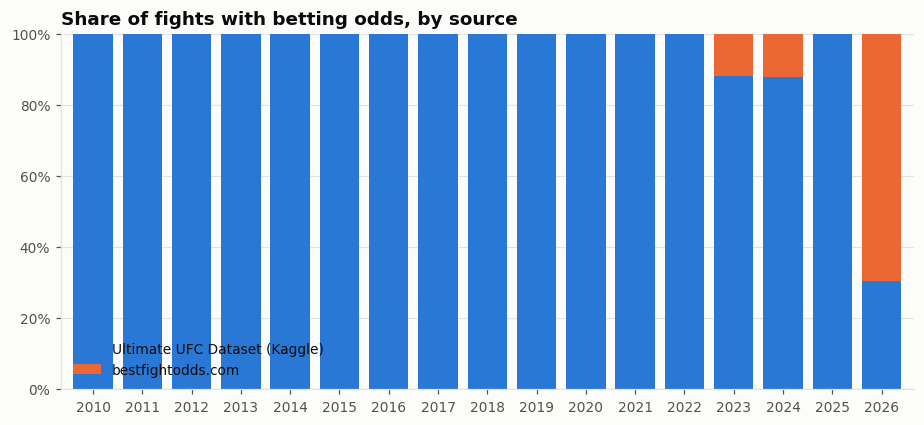

In [14]:
source = master[master['year'] >= 2010].groupby('year')['odds_source'].value_counts(normalize=True).unstack().fillna(0)
source = source.reindex(columns=['ultimate-ufc-dataset', 'bestfightodds'])
ax = source.plot.bar(stacked=True, width=0.8, color=[plotting.BLUE, plotting.ORANGE])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title('Share of fights with betting odds, by source')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Ultimate UFC Dataset (Kaggle)', 'bestfightodds.com'], loc='lower left')
plt.show()

About 95% of the fights of 2011-2022 have odds, from the Ultimate UFC Dataset. That dataset has gaps in 2023 and 2024 and ends in March 2026: bestfightodds.com fills most of them, and covers every event since. The comparisons with the market are always made on the fights that do have odds.

## 7. The betting market

The market is the benchmark every model is compared with. American odds are converted to implied probabilities, then normalised so that the two fighters' probabilities add up to 1 (removing the bookmaker's margin).

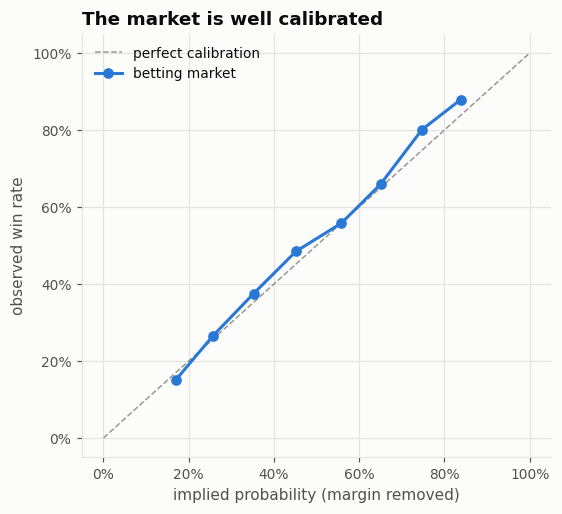

7,154 fights with odds. Median bookmaker margin: 3.8%. The favourite wins 66.7% of the time.


In [15]:
market = decided.dropna(subset=['r_odds', 'b_odds']).copy()
r_imp, b_imp = american_to_prob(market['r_odds']), american_to_prob(market['b_odds'])
market['p_r'] = r_imp / (r_imp + b_imp)
market['r_won'] = (market['outcome'] == 'r').astype(int)
margin = np.nanmedian(r_imp + b_imp - 1)

bins = np.linspace(0, 1, 11)
market['bin'] = pd.cut(market['p_r'], bins)
calibration = market.groupby('bin', observed=True).agg(predicted=('p_r', 'mean'),
                                                       observed=('r_won', 'mean'),
                                                       fights=('r_won', 'size'))
calibration = calibration[calibration['fights'] >= 30]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=plotting.NEUTRAL, linewidth=1, linestyle='--', label='perfect calibration')
ax.plot(calibration['predicted'], calibration['observed'], marker='o', color=plotting.BLUE,
        label='betting market')
ax.set_xlabel('implied probability (margin removed)')
ax.set_ylabel('observed win rate')
ax.set_title('The market is well calibrated')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='upper left')
plt.show()

favourite_won = ((market['p_r'] > 0.5) == (market['r_won'] == 1))[market['p_r'] != 0.5]
print(f"{len(market):,} fights with odds. Median bookmaker margin: {margin:.1%}. "
      f"The favourite wins {favourite_won.mean():.1%} of the time.")

In the middle of the range the market is right on target: fighters priced at 55% or 65% win about 56% and 66% of the time. The visible deviation is at the favourite end, where fighters priced at 75% or 84% win about 80% and 88% of the time, a little more than their odds imply (the classic favourite-longshot bias). A model can only beat the market by finding information the market misses, which is what [03_models_and_rankings](03_models_and_rankings.ipynb) tests.

## 8. Official rankings

The weekly snapshots of the official UFC rankings, read from the history of the Wikipedia article. Until June 2026 they were voted by a **media panel**; since then the UFC publishes the **Meta UFC Rankings**, computed by a rating model built with Meta, and the panel keeps running during the transition.

In [16]:
official = read_official_rankings(WIKI_RANKINGS_CSV, master)
summary = official.groupby('system').agg(snapshots=('date', 'nunique'), first=('date', 'min'), last=('date', 'max'),
                                         rows=('fighter', 'size'), matched=('fighter_id', lambda s: s.notna().mean()))
summary['first'] = summary['first'].dt.date
summary['last'] = summary['last'].dt.date
summary['matched'] = summary['matched'].map('{:.1%}'.format)
summary

,snapshots,first,last,rows,matched
system,,,,,
media,427,2018-01-06,2026-09-22,75039,100.0%
meta,14,2026-06-27,2026-09-22,2464,100.0%


`matched` is the share of ranked names linked to a ufcstats fighter: through the Wikipedia page the name links to (which follows name changes), then the name itself, then the closest name among the fighters of the division.

In [17]:
latest = official['date'].max()
week = official[(official['date'] == latest) & official['fighter_id'].notna()]
media = week[week['system'] == 'media'].set_index(['division', 'fighter_id'])['rank']
meta = week[week['system'] == 'meta'].set_index(['division', 'fighter_id'])['rank']
both = pd.concat({'media': media, 'meta': meta}, axis=1)

rows = []
for division, table in both.groupby(level='division'):
    shared = table.dropna()
    rows.append({'division': division, 'in both top 15 + champion': len(shared),
                 'Spearman (shared fighters)': spearmanr(shared['media'], shared['meta'])[0]})
print(f'Snapshot of {latest.date()}')
pd.DataFrame(rows).set_index('division').reindex(DIVISIONS).dropna().round(2)

Snapshot of 2026-09-22


,in both top 15 + champion,Spearman (shared fighters)
division,,
Flyweight,12.0,0.91
Bantamweight,14.0,0.83
Featherweight,12.0,0.98
Lightweight,13.0,0.96
Welterweight,15.0,0.93
Middleweight,15.0,0.96
Light Heavyweight,14.0,0.92
Heavyweight,12.0,0.92
Women's Strawweight,13.0,0.93


Three months after its launch, the model-based ranking mostly agrees with the journalists: in most divisions 12 to 15 of the 16 names (champion and top 15) are in both lists, in a very similar order. Women's bantamweight is the exception, with the two rankings ordering the same fighters quite differently. How our rankings compare with both official rankings, and which ranking best predicts the fights, is in [03_models_and_rankings](03_models_and_rankings.ipynb).

## 9. Professional records

For the fighters with a Wikipedia page, the pipeline also collects their whole professional record, inside and outside the UFC (`data/raw/wikipedia/records.csv`). A page is only linked to a fighter when its record table contains their UFC fights.

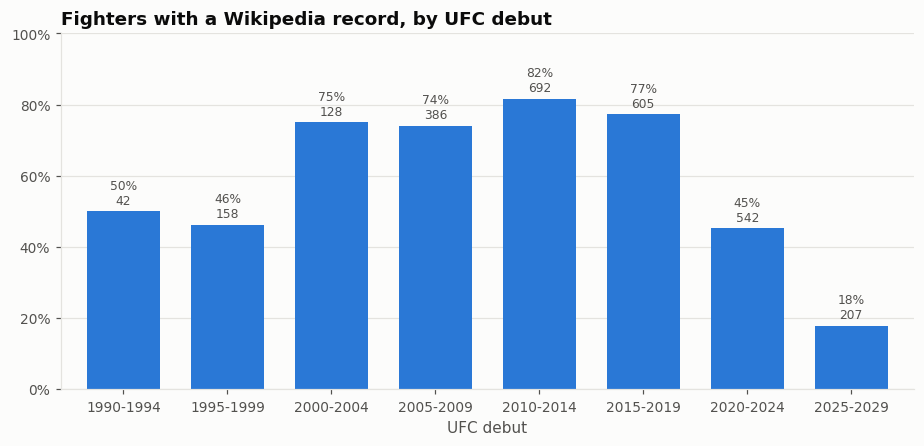

1,791 fighters, 46,223 professional fights. Before their UFC debut, the median fighter had 10 professional fights and won 84% of them on average.


In [18]:
records = pd.read_csv(WIKI_RECORDS_CSV, parse_dates=['date'])
appearances = pd.concat([master[['r_id', 'date']].set_axis(['fighter_id', 'date'], axis=1),
                         master[['b_id', 'date']].set_axis(['fighter_id', 'date'], axis=1)])
debut = appearances.groupby('fighter_id')['date'].min()
coverage = debut.to_frame('debut').assign(has_record=lambda d: d.index.isin(records['fighter_id']))
by_period = coverage.groupby(coverage['debut'].dt.year // 5 * 5)['has_record'].agg(['mean', 'size'])
by_period.index = [f'{y}-{y + 4}' for y in by_period.index]

ax = by_period['mean'].plot.bar(color=plotting.BLUE, width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title('Fighters with a Wikipedia record, by UFC debut')
ax.set_xlabel('UFC debut')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='x', visible=False)
for x, (share, n) in enumerate(by_period.itertuples(index=False)):
    ax.text(x, share + 0.02, f'{share:.0%}\n{n}', ha='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

first_ufc = records['fighter_id'].map(debut)
before = records[records['date'] < first_ufc].groupby('fighter_id')['result'].agg(
    fights='size', win_rate=lambda s: (s == 'win').mean())
print(f"{records['fighter_id'].nunique():,} fighters, {len(records):,} professional fights. "
      f"Before their UFC debut, the median fighter had {before['fights'].median():.0f} professional fights "
      f"and won {before['win_rate'].mean():.0%} of them on average.")

The coverage is the point to remember. Wikipedia keeps a page for the fighters who became notable, which mostly means those who lasted in the UFC: the fighters who debuted in the 2010s are covered about four times out of five, the recent ones much less, not because their record is unknown but because their career has not decided yet whether they get a page. Having a record in this table is therefore a hint about a fighter's *future*.

That is why these records are collected but not used by the models: a feature built from them would let the model learn from information that did not exist at fight time, the same kind of leak as the corner artefact of section 2.